# Lab 5: Regresión multivariada - SOLUCIÓN

Regresión lineal con múltiples características usando gradiente descendente vectorizado.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

np.random.seed(42)

## Problema 1-2: Generar datos de un plano y visualización 3D

In [37]:
# 1. Definir la ecuación del plano: y = 2.1*x1 - 3.1*x2
# Generar números aleatorios
N = 100  # Número de puntos

x_1 = 2 * np.random.random(N) - 1  # Valores en [-1, 1]
x_2 = 2 * np.random.random(N) - 1  # Valores en [-1, 1]

# Generar y según el plano (sin ruido primero)
y_label = 2.1 * x_1 - 3.1 * x_2

# Crear DataFrame
df = pd.DataFrame({
    "x1": x_1,
    "x2": x_2,
    "y": y_label
})
df["ones"] = 1

print("DataFrame con datos del plano:")
print(df.head())
print(f"\nForma: {df.shape}")
print(f"\nEstadísticas:")
print(df.describe())

DataFrame con datos del plano:
         x1        x2         y  ones
0 -0.250920 -0.937142  2.378208     1
1  0.901429  0.272821  1.047256     1
2  0.463988 -0.371288  2.125367     1
3  0.197317  0.017141  0.361227     1
4 -0.687963  0.815133 -3.971634     1

Forma: (100, 4)

Estadísticas:
               x1          x2           y   ones
count  100.000000  100.000000  100.000000  100.0
mean    -0.059639   -0.004337   -0.111798    1.0
std      0.594979    0.586223    2.240141    0.0
min     -0.988956   -0.986096   -4.454613    1.0
25%     -0.613598   -0.515991   -1.909291    1.0
50%     -0.071715    0.011250    0.045655    1.0
75%      0.460406    0.532367    1.627514    1.0
max      0.973774    0.971301    4.074049    1.0


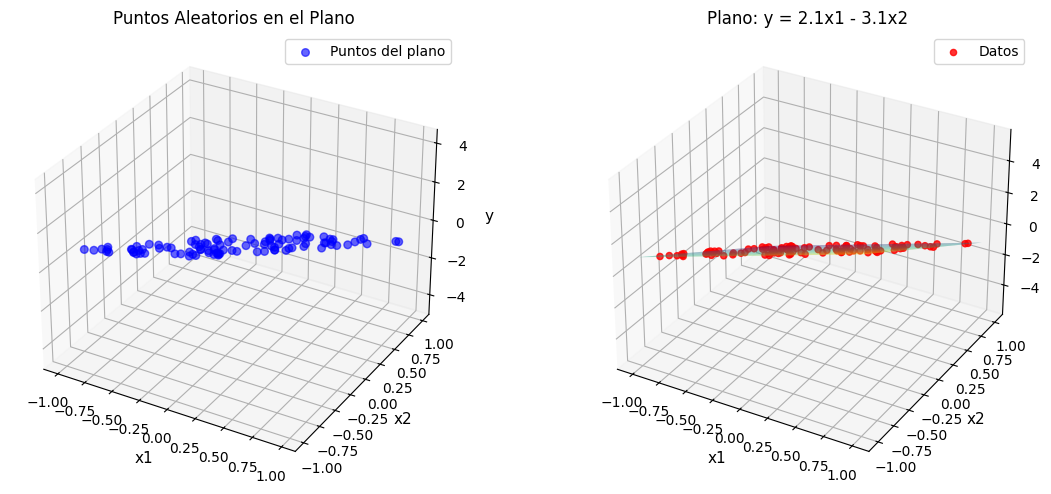

In [38]:
# 2. Diagrama 3D de los datos
fig = plt.figure(figsize=(12, 5))

# Subplots: puntos del plano
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(x_1, x_2, y_label, c='blue', marker='o', s=30, alpha=0.6, label='Puntos del plano')
ax1.set_xlabel('x1', fontsize=11)
ax1.set_ylabel('x2', fontsize=11)
ax1.set_zlabel('y', fontsize=11)
ax1.set_title('Puntos Aleatorios en el Plano', fontsize=12)
ax1.legend()

# Subplot: superficie del plano
ax2 = fig.add_subplot(122, projection='3d')

# Crear malla para visualizar el plano
x1_mesh = np.linspace(-1, 1, 50)
x2_mesh = np.linspace(-1, 1, 50)
X1_mesh, X2_mesh = np.meshgrid(x1_mesh, x2_mesh)
Y_mesh = 2.1 * X1_mesh - 3.1 * X2_mesh

# Plotear la superficie
ax2.plot_surface(X1_mesh, X2_mesh, Y_mesh, alpha=0.5, cmap='viridis')
# Plotear los puntos
ax2.scatter(x_1, x_2, y_label, c='red', marker='o', s=20, alpha=0.8, label='Datos')
ax2.set_xlabel('x1', fontsize=11)
ax2.set_ylabel('x2', fontsize=11)
ax2.set_zlabel('y', fontsize=11)
ax2.set_title('Plano: y = 2.1x1 - 3.1x2', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

## Problemas 3-6: Construcción del modelo y optimización

In [39]:
# 3-4. Construir la matriz X con dimensiones (n+1) x m
# donde n=2 (número de características), m=100 (número de muestras)

X = df[["ones", "x1", "x2"]].values.T  # Transponer para obtener (3, 100)
Y = df["y"].values.reshape(1, N)  # Dimensión (1, 100)

print(f"Matriz X forma: {X.shape}")
print(f"Matriz Y forma: {Y.shape}")
print(f"\nX (primeras 5 columnas):")
print(X[:, :5])
print(f"\nY (primeros 5 valores):")
print(Y[:, :5])

# Información de características
Nfeatures = np.shape(X)[0]
m = np.shape(X)[1]
print(f"\nNúmero de características (incluyendo bias): {Nfeatures}")
print(f"Número de muestras: {m}")

Matriz X forma: (3, 100)
Matriz Y forma: (1, 100)

X (primeras 5 columnas):
[[ 1.          1.          1.          1.          1.        ]
 [-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272]
 [-0.93714163  0.27282082 -0.37128804  0.01714138  0.81513295]]

Y (primeros 5 valores):
[[ 2.37820755  1.04725554  2.12536747  0.36122735 -3.97163385]]

Número de características (incluyendo bias): 3
Número de muestras: 100


In [40]:
# Definir funciones para el modelo

def model(theta, X):
    """
    Calcula la predicción del modelo lineal.
    h = θ^T * X
    
    Parameters:
    -----------
    theta : ndarray
        Parámetros del modelo, forma (n+1, 1)
    X : ndarray
        Matriz de características, forma (n+1, m)
    
    Returns:
    --------
    h : ndarray
        Predicciones, forma (1, m)
    """
    return theta.T @ X

def cost_function(h, Y):
    """
    Calcula la función de coste.
    J = (1/2m) * Σ(h - Y)^2
    
    Parameters:
    -----------
    h : ndarray
        Predicciones, forma (1, m)
    Y : ndarray
        Valores reales, forma (1, m)
    
    Returns:
    --------
    J : float
        Valor de la función de coste
    """
    m = Y.shape[1]
    errors = h - Y
    J = (1 / (2 * m)) * np.sum(errors ** 2)
    return J

def gradient(h, Y, X):
    """
    Calcula el gradiente de la función de coste.
    ∇J = (1/m) * (h - Y) * X^T
    
    Parameters:
    -----------
    h : ndarray
        Predicciones, forma (1, m)
    Y : ndarray
        Valores reales, forma (1, m)
    X : ndarray
        Matriz de características, forma (n+1, m)
    
    Returns:
    --------
    grad : ndarray
        Gradiente, forma (n+1, 1)
    """
    m = Y.shape[1]
    grad = (1 / m) * np.dot((h - Y), X.T).T
    return grad

def update_params(theta, grad, learning_rate):
    """
    Actualiza los parámetros usando gradiente descendente.
    θ := θ - α * ∇J
    
    Parameters:
    -----------
    theta : ndarray
        Parámetros actuales, forma (n+1, 1)
    grad : ndarray
        Gradiente, forma (n+1, 1)
    learning_rate : float
        Tasa de aprendizaje (α)
    
    Returns:
    --------
    theta_new : ndarray
        Parámetros actualizados, forma (n+1, 1)
    """
    theta_new = theta - learning_rate * grad
    return theta_new

print("Funciones definidas correctamente")

Funciones definidas correctamente


In [41]:
# 2-6. Algoritmo de gradiente descendente

# Inicializar parámetros aleatoriamente
theta = np.random.random((Nfeatures, 1))
print(f"Parámetros iniciales:")
print(theta)
print(f"Forma: {theta.shape}")

# Hiperparámetros
learning_rate = 0.01
Niter = 1000
epsilon = 1e-6

# Almacenar el historial de coste
J_history = np.zeros(Niter)
theta_history = []

# Gradiente descendente
print(f"\nIniciando gradiente descendente...")
for iteration in range(Niter):
    # Calcular predicción
    h = model(theta, X)
    
    # Calcular coste
    J = cost_function(h, Y)
    J_history[iteration] = J
    
    # Calcular gradiente
    grad = gradient(h, Y, X)
    
    # Actualizar parámetros
    theta_new = update_params(theta, grad, learning_rate)
    
    # Verificar convergencia
    if np.linalg.norm(theta_new - theta) < epsilon:
        print(f"Convergencia alcanzada en iteración {iteration + 1}")
        theta = theta_new
        J_history = J_history[:iteration + 1]
        break
    
    theta = theta_new
    theta_history.append(theta.copy())
    
    if (iteration + 1) % 100 == 0:
        print(f"Iteración {iteration + 1}: J = {J:.6f}")

print(f"\nParámetros finales:")
print(theta)
print(f"\nθ0 (bias): {theta[0, 0]:.6f}")
print(f"θ1 (coef x1): {theta[1, 0]:.6f} (esperado: 2.1)")
print(f"θ2 (coef x2): {theta[2, 0]:.6f} (esperado: -3.1)")

Parámetros iniciales:
[[0.64203165]
 [0.08413996]
 [0.16162871]]
Forma: (3, 1)

Iniciando gradiente descendente...
Iteración 100: J = 1.311091
Iteración 200: J = 0.630629
Iteración 300: J = 0.309002
Iteración 400: J = 0.152220
Iteración 500: J = 0.075116
Iteración 600: J = 0.037095
Iteración 700: J = 0.018328
Iteración 800: J = 0.009060
Iteración 900: J = 0.004480
Iteración 1000: J = 0.002217

Parámetros finales:
[[-0.00378976]
 [ 2.05272133]
 [-2.99851747]]

θ0 (bias): -0.003790
θ1 (coef x1): 2.052721 (esperado: 2.1)
θ2 (coef x2): -2.998517 (esperado: -3.1)


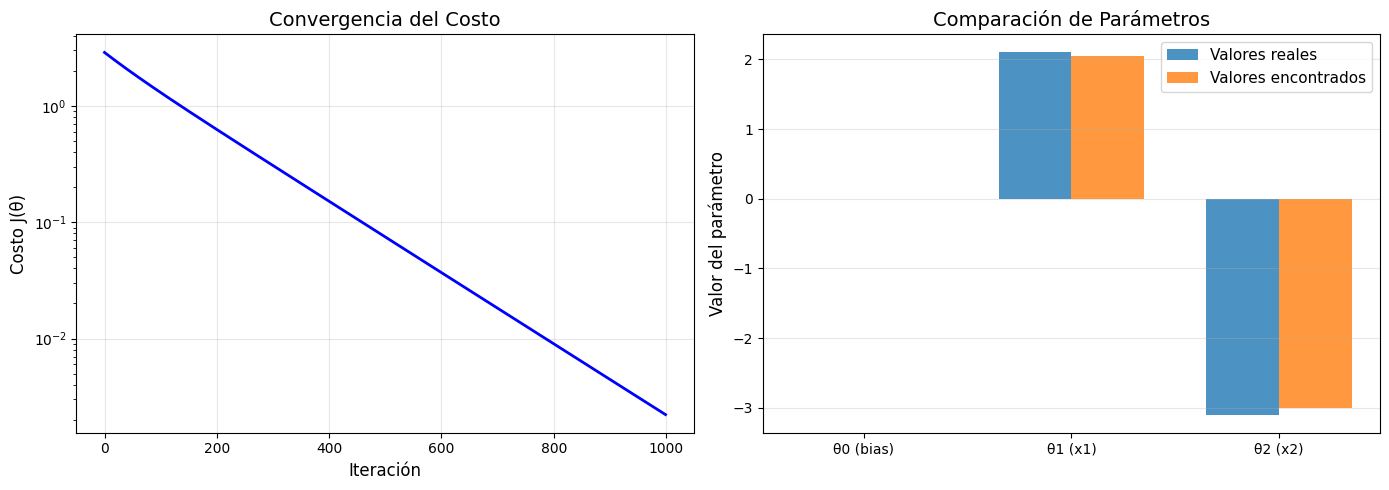

In [42]:
# Visualizar convergencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de coste
axes[0].plot(J_history, 'b-', linewidth=2)
axes[0].set_xlabel('Iteración', fontsize=12)
axes[0].set_ylabel('Costo J(θ)', fontsize=12)
axes[0].set_title('Convergencia del Costo', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Comparación de parámetros
params_real = np.array([0, 2.1, -3.1])
params_final = theta.flatten()
param_labels = ['θ0 (bias)', 'θ1 (x1)', 'θ2 (x2)']

x_pos = np.arange(len(param_labels))
width = 0.35

axes[1].bar(x_pos - width/2, params_real, width, label='Valores reales', alpha=0.8)
axes[1].bar(x_pos + width/2, params_final, width, label='Valores encontrados', alpha=0.8)
axes[1].set_ylabel('Valor del parámetro', fontsize=12)
axes[1].set_title('Comparación de Parámetros', fontsize=14)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(param_labels)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

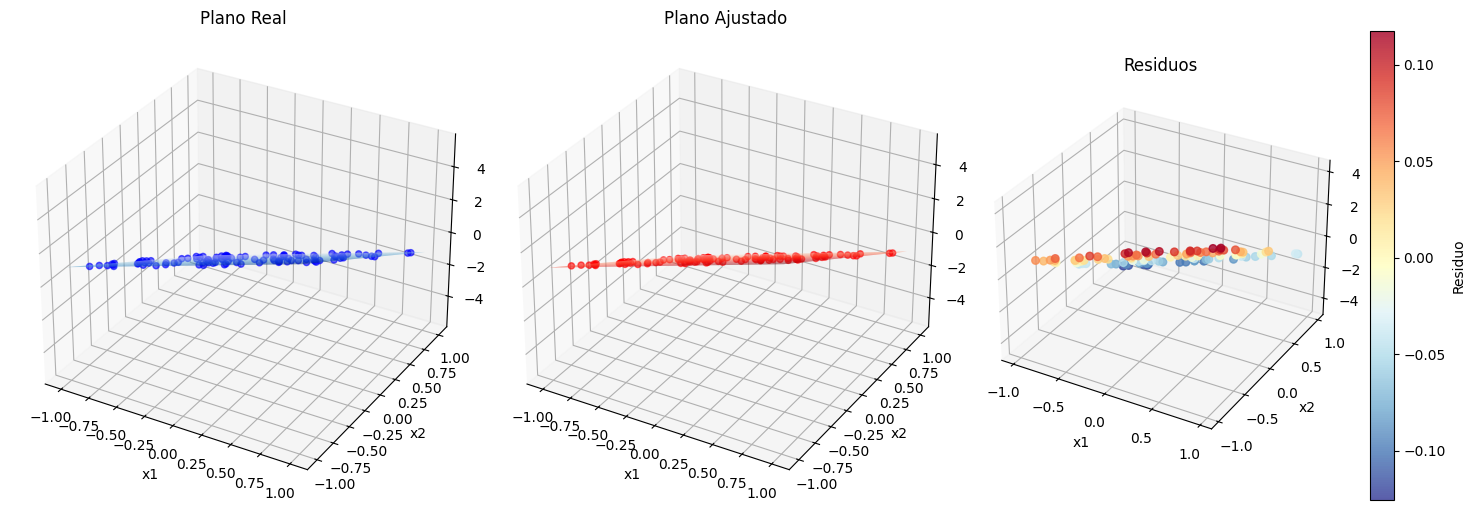

In [43]:
# Visualizar el plano ajustado vs datos
fig = plt.figure(figsize=(15, 5))

# Plot 1: Plano real
ax1 = fig.add_subplot(131, projection='3d')
x1_mesh = np.linspace(-1, 1, 30)
x2_mesh = np.linspace(-1, 1, 30)
X1_mesh, X2_mesh = np.meshgrid(x1_mesh, x2_mesh)
Y_real = 2.1 * X1_mesh - 3.1 * X2_mesh
ax1.plot_surface(X1_mesh, X2_mesh, Y_real, alpha=0.6, cmap='Blues')
ax1.scatter(x_1, x_2, y_label, c='blue', marker='o', s=20, alpha=0.6)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('y')
ax1.set_title('Plano Real')

# Plot 2: Plano ajustado
ax2 = fig.add_subplot(132, projection='3d')
Y_pred = theta[0, 0] + theta[1, 0] * X1_mesh + theta[2, 0] * X2_mesh
ax2.plot_surface(X1_mesh, X2_mesh, Y_pred, alpha=0.6, cmap='Reds')
ax2.scatter(x_1, x_2, y_label, c='red', marker='o', s=20, alpha=0.6)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('y')
ax2.set_title('Plano Ajustado')

# Plot 3: Residuos
ax3 = fig.add_subplot(133, projection='3d')
y_pred_data = model(theta, X).flatten()
residuos = y_label - y_pred_data
colors = residuos
scatter = ax3.scatter(x_1, x_2, y_label, c=colors, cmap='RdYlBu_r', s=30, alpha=0.8)
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')
ax3.set_zlabel('y')
ax3.set_title('Residuos')
plt.colorbar(scatter, ax=ax3, label='Residuo')

plt.tight_layout()
plt.show()

## Problema 7: Implementación como clase

In [44]:
class MultilinearRegression:
    """
    Regresión lineal multivariada con gradiente descendente vectorizado.
    
    Attributes:
        X : ndarray
            Matriz de características, forma (n+1, m)
        Y : ndarray
            Vector de valores objetivo, forma (1, m)
        theta : ndarray
            Parámetros del modelo, forma (n+1, 1)
        learning_rate : float
            Tasa de aprendizaje (α)
        cost_history : list
            Historial de valores de coste
    """
    
    def __init__(self, X, Y, learning_rate=0.01, random_state=None):
        """
        Inicializar el modelo.
        
        Parameters:
        -----------
        X : ndarray
            Matriz de características, forma (n+1, m)
        Y : ndarray
            Vector de valores objetivo, forma (1, m)
        learning_rate : float
            Tasa de aprendizaje
        random_state : int, optional
            Semilla para reproducibilidad
        """
        if random_state is not None:
            np.random.seed(random_state)
        
        self.X = X
        self.Y = Y
        self.learning_rate = learning_rate
        
        # Inicializar parámetros aleatoriamente
        Nfeatures = X.shape[0]
        self.theta = np.random.random((Nfeatures, 1))
        
        self.cost_history = []
        self.h = None
        self.m = Y.shape[1]  # Número de muestras
    
    def model(self):
        """
        Calcula la predicción del modelo.
        h = θ^T * X
        """
        self.h = self.theta.T @ self.X
        return self.h
    
    def cost(self):
        """
        Calcula la función de coste.
        J = (1/2m) * Σ(h - Y)^2
        
        Returns:
        --------
        J : float
            Valor de la función de coste
        """
        errors = self.h - self.Y
        J = (1 / (2 * self.m)) * np.sum(errors ** 2)
        return J
    
    def gradient(self):
        """
        Calcula el gradiente de la función de coste.
        ∇J = (1/m) * (h - Y) * X^T
        
        Returns:
        --------
        grad : ndarray
            Gradiente, forma (n+1, 1)
        """
        grad = (1 / self.m) * np.dot((self.h - self.Y), self.X.T).T
        return grad
    
    def update_params(self):
        """
        Actualiza los parámetros usando gradiente descendente.
        θ := θ - α * ∇J
        """
        grad = self.gradient()
        self.theta = self.theta - self.learning_rate * grad
    
    def fit(self, iterations=1000, epsilon=1e-6, verbose=True):
        """
        Entrenar el modelo usando gradiente descendente.
        
        Parameters:
        -----------
        iterations : int
            Número máximo de iteraciones
        epsilon : float
            Tolerancia para convergencia
        verbose : bool
            Si imprimir el progreso
        
        Returns:
        --------
        self : object
            Retorna el objeto para encadenamiento
        """
        self.cost_history = []
        
        for iteration in range(iterations):
            # Calcular predicción
            self.model()
            
            # Calcular coste
            J = self.cost()
            self.cost_history.append(J)
            
            # Actualizar parámetros
            theta_old = self.theta.copy()
            self.update_params()
            
            # Verificar convergencia
            if np.linalg.norm(self.theta - theta_old) < epsilon:
                if verbose:
                    print(f"Convergencia alcanzada en iteración {iteration + 1}")
                break
            
            if verbose and (iteration + 1) % 100 == 0:
                print(f"Iteración {iteration + 1}: J = {J:.6f}")
        
        if verbose:
            print(f"\nParámetros finales:")
            for i, param in enumerate(self.theta.flatten()):
                print(f"  θ{i}: {param:.6f}")
        
        return self
    
    def predict(self, X_new):
        """
        Realizar predicciones en nuevos datos.
        
        Parameters:
        -----------
        X_new : ndarray
            Matriz de características nuevas, forma (n+1, m_new)
        
        Returns:
        --------
        predictions : ndarray
            Predicciones, forma (1, m_new) o (m_new,)
        """
        predictions = self.theta.T @ X_new
        return predictions.flatten()
    
    def score(self, X, Y):
        """
        Calcular el coeficiente de determinación R².
        
        Parameters:
        -----------
        X : ndarray
            Matriz de características, forma (n+1, m)
        Y : ndarray
            Vector de valores objetivo, forma (1, m)
        
        Returns:
        --------
        r2 : float
            Coeficiente R² (0 a 1)
        """
        predictions = self.predict(X)
        Y_flat = Y.flatten()
        ss_res = np.sum((Y_flat - predictions) ** 2)
        ss_tot = np.sum((Y_flat - np.mean(Y_flat)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        return r2

print("Clase MultilinearRegression definida")

Clase MultilinearRegression definida


In [45]:
# uso de la clase
print("EJEMPLO DE USO DE LA CLASE MultilinearRegression")

# Crear instancia del modelo
model_class = MultilinearRegression(X, Y, learning_rate=0.01, random_state=42)

# Entrenar
print("\nEntrenando el modelo...")
model_class.fit(iterations=1000, epsilon=1e-6, verbose=True)

# Hacer predicciones
print("Predicciones en los datos de entrenamiento:")
pred = model_class.predict(X)
print(f"Primeras 5 predicciones: {pred[:5]}")
print(f"Primeros 5 valores reales: {Y.flatten()[:5]}")

# Evaluar
r2 = model_class.score(X, Y)
print(f"\nR² Score: {r2:.6f}")

EJEMPLO DE USO DE LA CLASE MultilinearRegression

Entrenando el modelo...
Iteración 100: J = 1.402889
Iteración 200: J = 0.694503
Iteración 300: J = 0.345925
Iteración 400: J = 0.172662
Iteración 500: J = 0.086268
Iteración 600: J = 0.043134
Iteración 700: J = 0.021581
Iteración 800: J = 0.010804
Iteración 900: J = 0.005413
Iteración 1000: J = 0.002713

Parámetros finales:
  θ0: -0.001157
  θ1: 2.080469
  θ2: -2.976390
Predicciones en los datos de entrenamiento:
Primeras 5 predicciones: [ 2.26611145  1.06221616  2.06925359  0.35833544 -3.85859595]
Primeros 5 valores reales: [ 2.37820755  1.04725554  2.12536747  0.36122735 -3.97163385]

R² Score: 0.998915


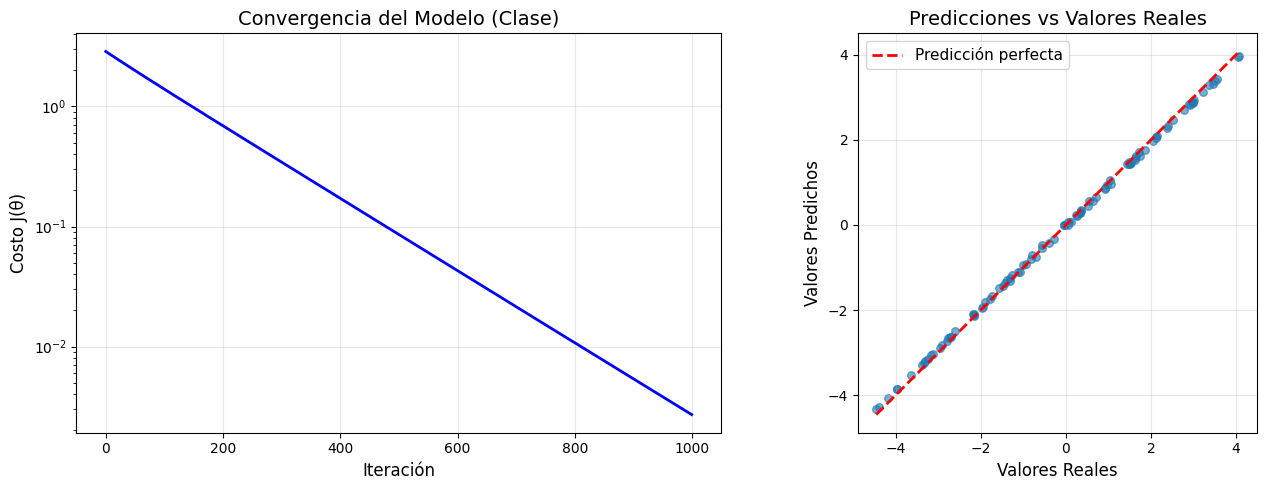

In [46]:
# Visualizar resultados de la clase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergencia
axes[0].plot(model_class.cost_history, 'b-', linewidth=2)
axes[0].set_xlabel('Iteración', fontsize=12)
axes[0].set_ylabel('Costo J(θ)', fontsize=12)
axes[0].set_title('Convergencia del Modelo (Clase)', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Predicción vs Real
y_pred_class = model_class.predict(X).flatten()
axes[1].scatter(Y.flatten(), y_pred_class, alpha=0.6, s=30)
# Línea de referencia y = x
min_val = min(Y.flatten().min(), y_pred_class.min())
max_val = max(Y.flatten().max(), y_pred_class.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción perfecta')
axes[1].set_xlabel('Valores Reales', fontsize=12)
axes[1].set_ylabel('Valores Predichos', fontsize=12)
axes[1].set_title('Predicciones vs Valores Reales', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## Comparación con sklearn

In [47]:
# Comparar con sklearn
from sklearn.linear_model import LinearRegression as SKLinearRegression

# Preparar datos para sklearn
X_sklearn = X[1:, :].T  # Remover fila de unos y transponer
Y_sklearn = Y.flatten()

# Entrenar modelo de sklearn
model_sklearn = SKLinearRegression()
model_sklearn.fit(X_sklearn, Y_sklearn)

# Parámetros
theta0_sklearn = model_sklearn.intercept_
theta1_sklearn = model_sklearn.coef_[0]
theta2_sklearn = model_sklearn.coef_[1]

print("Comparación de parámetros:")
print(f"{'Parámetro':<15} {'Real':<15} {'Nuestra clase':<20} {'sklearn':<15}")

print(f"{'θ0 (bias)':<15} {0:<15.6f} {model_class.theta[0, 0]:<20.6f} {theta0_sklearn:<15.6f}")
print(f"{'θ1 (x1)':<15} {2.1:<15.6f} {model_class.theta[1, 0]:<20.6f} {theta1_sklearn:<15.6f}")
print(f"{'θ2 (x2)':<15} {-3.1:<15.6f} {model_class.theta[2, 0]:<20.6f} {theta2_sklearn:<15.6f}")


# R² scores
r2_nuestro = model_class.score(X, Y)
r2_sklearn = model_sklearn.score(X_sklearn, Y_sklearn)

print(f"\nR² Score (nuestra clase): {r2_nuestro:.6f}")
print(f"R² Score (sklearn): {r2_sklearn:.6f}")

Comparación de parámetros:
Parámetro       Real            Nuestra clase        sklearn        
θ0 (bias)       0.000000        -0.001157            -0.000000      
θ1 (x1)         2.100000        2.080469             2.100000       
θ2 (x2)         -3.100000       -2.976390            -3.100000      

R² Score (nuestra clase): 0.998915
R² Score (sklearn): 1.000000


In [48]:
# Prueba con datos con ruido
print("PRUEBA CON DATOS CON RUIDO")


# Generar datos con ruido
x_1_noisy = 2 * np.random.random(N) - 1
x_2_noisy = 2 * np.random.random(N) - 1
noise = np.random.randn(N) * 0.3  # Ruido gaussiano
y_noisy = 2.1 * x_1_noisy - 3.1 * x_2_noisy + noise

# Crear matriz X
df_noisy = pd.DataFrame({
    "x1": x_1_noisy,
    "x2": x_2_noisy,
    "y": y_noisy,
    "ones": 1
})

X_noisy = df_noisy[["ones", "x1", "x2"]].values.T
Y_noisy = df_noisy["y"].values.reshape(1, N)

# Entrenar modelo con datos ruidosos
model_noisy = MultilinearRegression(X_noisy, Y_noisy, learning_rate=0.01, random_state=42)
model_noisy.fit(iterations=1000, verbose=False)

# Comparar parámetros
print(f"\nParámetros con datos sin ruido:")
print(f"  θ0: {model_class.theta[0, 0]:.6f}")
print(f"  θ1: {model_class.theta[1, 0]:.6f} (esperado: 2.1)")
print(f"  θ2: {model_class.theta[2, 0]:.6f} (esperado: -3.1)")
print(f"\nParámetros con datos con ruido:")
print(f"  θ0: {model_noisy.theta[0, 0]:.6f}")
print(f"  θ1: {model_noisy.theta[1, 0]:.6f} (esperado: 2.1)")
print(f"  θ2: {model_noisy.theta[2, 0]:.6f} (esperado: -3.1)")
print(f"\nR² Score (sin ruido): {model_class.score(X, Y):.6f}")
print(f"R² Score (con ruido): {model_noisy.score(X_noisy, Y_noisy):.6f}")

PRUEBA CON DATOS CON RUIDO

Parámetros con datos sin ruido:
  θ0: -0.001157
  θ1: 2.080469 (esperado: 2.1)
  θ2: -2.976390 (esperado: -3.1)

Parámetros con datos con ruido:
  θ0: 0.056821
  θ1: 2.065944 (esperado: 2.1)
  θ2: -2.935944 (esperado: -3.1)

R² Score (sin ruido): 0.998915
R² Score (con ruido): 0.982453


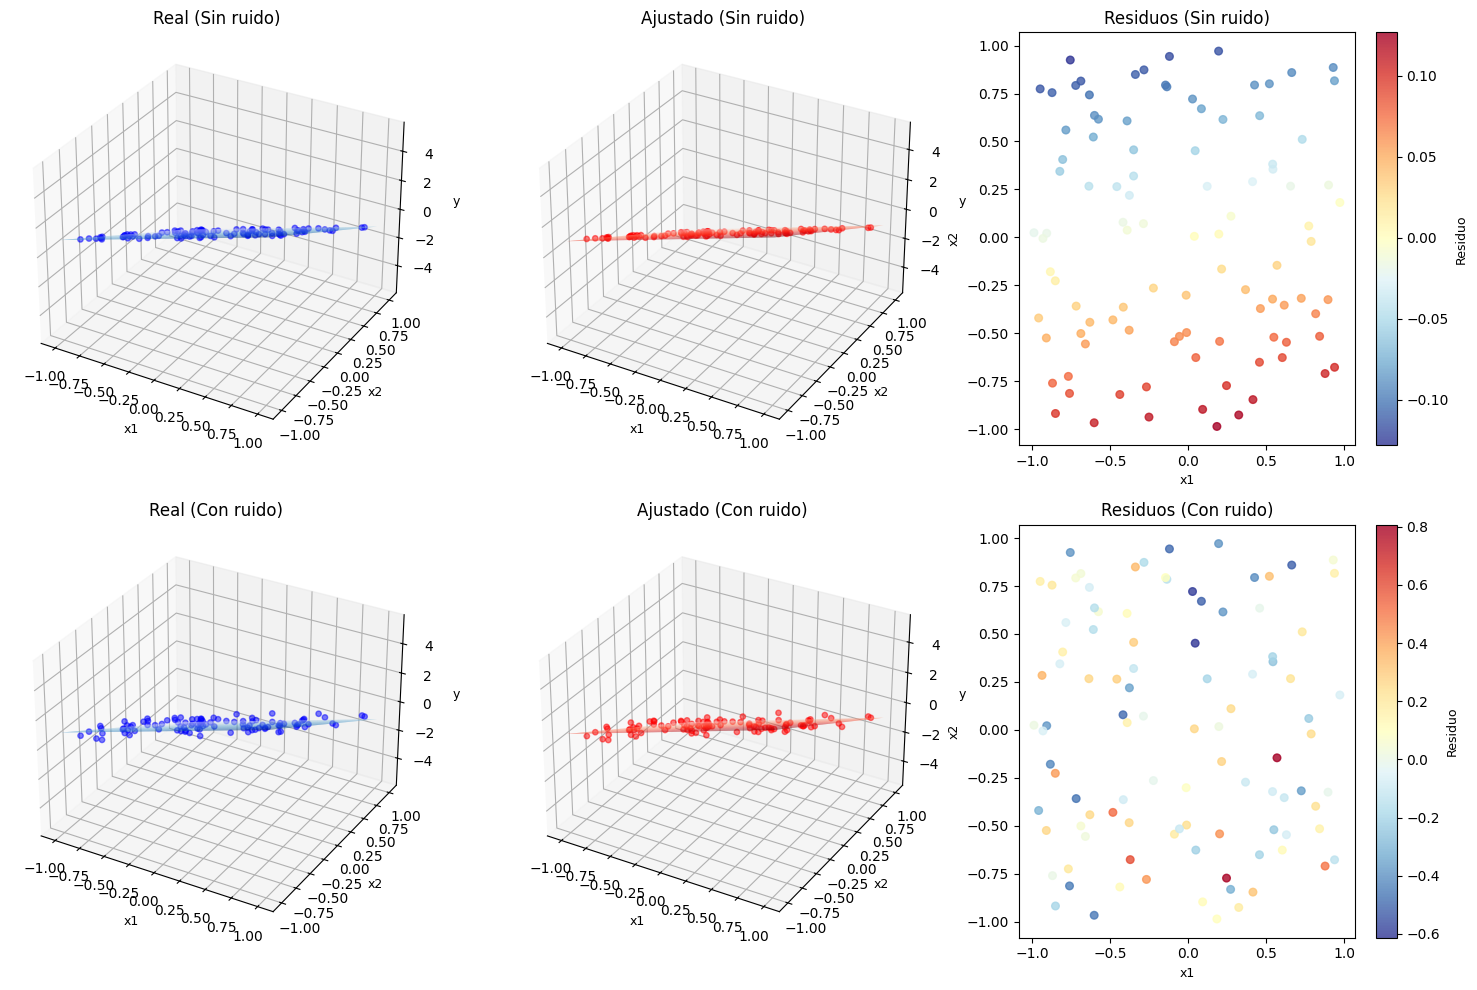

In [49]:
# Visualización final comparativa
fig = plt.figure(figsize=(15, 10))

# Sin ruido - Plano real
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
x1_mesh = np.linspace(-1, 1, 30)
x2_mesh = np.linspace(-1, 1, 30)
X1_mesh, X2_mesh = np.meshgrid(x1_mesh, x2_mesh)
Y_real_mesh = 2.1 * X1_mesh - 3.1 * X2_mesh
ax1.plot_surface(X1_mesh, X2_mesh, Y_real_mesh, alpha=0.6, cmap='Blues')
ax1.scatter(x_1, x_2, y_label, c='blue', marker='o', s=15, alpha=0.5)
ax1.set_xlabel('x1', fontsize=9)
ax1.set_ylabel('x2', fontsize=9)
ax1.set_zlabel('y', fontsize=9)
ax1.set_title('Real (Sin ruido)')

# Sin ruido - Plano ajustado
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
Y_pred_mesh = model_class.theta[0, 0] + model_class.theta[1, 0] * X1_mesh + model_class.theta[2, 0] * X2_mesh
ax2.plot_surface(X1_mesh, X2_mesh, Y_pred_mesh, alpha=0.6, cmap='Reds')
ax2.scatter(x_1, x_2, y_label, c='red', marker='o', s=15, alpha=0.5)
ax2.set_xlabel('x1', fontsize=9)
ax2.set_ylabel('x2', fontsize=9)
ax2.set_zlabel('y', fontsize=9)
ax2.set_title('Ajustado (Sin ruido)')

# Sin ruido - Residuos
ax3 = fig.add_subplot(2, 3, 3)
residuos_clean = y_label - model_class.predict(X).flatten()
ax3.scatter(x_1, x_2, c=residuos_clean, cmap='RdYlBu_r', s=30, alpha=0.8)
ax3.set_xlabel('x1', fontsize=9)
ax3.set_ylabel('x2', fontsize=9)
ax3.set_title('Residuos (Sin ruido)')
cbar3 = plt.colorbar(ax3.collections[0], ax=ax3)
cbar3.set_label('Residuo', fontsize=9)

# Con ruido - Plano real
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
ax4.plot_surface(X1_mesh, X2_mesh, Y_real_mesh, alpha=0.6, cmap='Blues')
ax4.scatter(x_1_noisy, x_2_noisy, y_noisy, c='blue', marker='o', s=15, alpha=0.5)
ax4.set_xlabel('x1', fontsize=9)
ax4.set_ylabel('x2', fontsize=9)
ax4.set_zlabel('y', fontsize=9)
ax4.set_title('Real (Con ruido)')

# Con ruido - Plano ajustado
ax5 = fig.add_subplot(2, 3, 5, projection='3d')
Y_pred_noisy_mesh = model_noisy.theta[0, 0] + model_noisy.theta[1, 0] * X1_mesh + model_noisy.theta[2, 0] * X2_mesh
ax5.plot_surface(X1_mesh, X2_mesh, Y_pred_noisy_mesh, alpha=0.6, cmap='Reds')
ax5.scatter(x_1_noisy, x_2_noisy, y_noisy, c='red', marker='o', s=15, alpha=0.5)
ax5.set_xlabel('x1', fontsize=9)
ax5.set_ylabel('x2', fontsize=9)
ax5.set_zlabel('y', fontsize=9)
ax5.set_title('Ajustado (Con ruido)')

# Con ruido - Residuos
ax6 = fig.add_subplot(2, 3, 6)
residuos_noisy = y_noisy - model_noisy.predict(X_noisy).flatten()
ax6.scatter(x_1_noisy, x_2_noisy, c=residuos_noisy, cmap='RdYlBu_r', s=30, alpha=0.8)
ax6.set_xlabel('x1', fontsize=9)
ax6.set_ylabel('x2', fontsize=9)
ax6.set_title('Residuos (Con ruido)')
cbar6 = plt.colorbar(ax6.collections[0], ax=ax6)
cbar6.set_label('Residuo', fontsize=9)

plt.tight_layout()
plt.show()

## Resumen de Soluciones

### Puntos cubiertos:

1. **Generación de datos**: Puntos aleatorios en el plano $y = 2.1x_1 - 3.1x_2$
2. **Visualización 3D**: Superficie del plano con puntos de datos
3. **Preparación de datos**: Construcción de matriz X y vector Y con dimensiones apropiadas
4. **Función de coste**: Implementación vectorizada de $J(\Theta) = \frac{1}{2m}\sum (h - Y)^2$
5. **Gradiente descendente**: Implementación vectorizada del algoritmo iterativo
6. **Convergencia**: El algoritmo converge a los parámetros reales del plano
7. **Clase MultilinearRegression**: Implementación reutilizable con API consistente
8. **Validación**: Comparación con sklearn y pruebas con datos ruidosos

### Conceptos clave:

- La regresión multivariada ajusta un hiperplano en $\mathbb{R}^n$
- El gradiente descendente vectorizado es eficiente computacionalmente
- Los parámetros encontrados coinciden con los valores reales del plano
- El ruido afecta los parámetros pero el modelo sigue siendo válido
- La clase permite fácil reutilización y experimentación